# Cubee: AI & Q-Learning Analysis - MERTINAJ Erinald & Rubin

## 1. Overview

Ce projet est composé de **trois jeux différents**, chacun intégrant une intelligence artificielle.

L'objectif du projet était non seulement de développer des jeux fonctionnels, mais également d'explorer différentes approches permettant à une intelligence artificielle de prendre des décisions et d'améliorer son comportement au cours des parties.  
Pour cette présentation, nous nous concentrerons principalement sur **Cubee**, le jeu dans lequel nous avons implémenté un agent utilisant le **Q-learning** et une **Q-table**.  
Cette analyse nous permettra d'étudier l'influence de différents paramètres d'apprentissage sur le comportement et les performances de l'agent, ainsi que de comparer différentes méthodes d'entraînement.

## 2. Cubee

**Cubee** est un jeu se déroulant sur une grille de **5 × 5 cases** par defaut.

Deux joueurs s'affrontent afin de gagner le plus de territoire possible. Les joueurs se déplacent sur la grille et peuvent prendre possession de cases qui ne sont pas encore occupées.

Le jeu implique donc plusieurs éléments intéressants du point de vue de l'intelligence artificielle comme la prise de décision à chaque déplacement, l'exploration des différentes configurations possibles du plateau, la prise en compte des conséquences futures d'une action, et l'adaptation de la stratégie au comportement de l'adversaire.

Ces caractéristiques font de Cubee un environnement adapté à l'expérimentation avec le **reinforcement learning**.

## 3. Architecture

Le projet est organisé selon une architecture en **quatre couches**, avec une séparation claire entre l'affichage, le contrôle, la logique du jeu et les données.

L'organisation peut être représentée comme suit:
$$
\boxed{GUI \leftarrow Controller \rightarrow Engine \rightarrow Model}
$$
Les flèches représentent les dépendances entre les différentes couches : une couche peut accéder aux fonctionnalités de la couche vers laquelle elle pointe.

### GUI - Graphical User Interface

L'interface graphique constitue la couche de présentation du projet. Elle est développée avec **Tkinter**.  
Elle est uniquement responsable de l'affichage et ne contient pas la logique du jeu. Elle n'a pas directement accès au `Controller`, à l'`Engine` ou au `Model`.

Son rôle est notamment d'afficher:  
- le plateau de jeu
- les joueurs et leurs territoires
- les actions et informations pertinentes
- ainsi que l'état actuel de la partie

Les interactions de l'utilisateur sont transmises au `Controller`, qui est chargé de les traiter.

### Controller

Cette couche joue le rôle d'intermédiaire et d'orchestrateur entre l'interface et le reste du jeu.

Il est responsable de:
- recevoir les actions de l'utilisateur depuis la GUI
- demander à l'Engine d'exécuter les actions correspondantes
- interpréter les réponses de l'Engine et mettre à jour la GUI en conséquence

Le Controller est donc la seule couche qui fait le lien entre l'interface graphique et la logique du jeu.

### Engine

L'**Engine** contient exclusivement les règles et la logique du jeu.

Il détermine notamment:
- si une action est valide
- comment le jeu évolue après une action
- comment les règles de déplacement sont appliquées
- comment les territoires sont attribués
- et quand une partie est terminée

L'Engine ne s'occupe pas de l'affichage ni des interactions avec l'utilisateur.  
Pour effectuer ces opérations, il utilise les données fournies par le `Model`.

### Model

Le **Model** contient les données et l'état courant de la partie.  
Il contient notamment les informations nécessaires pour représenter :

- l'état du plateau
- les joueurs
- les cases revendiquées
- les positions des joueurs
- ainsi que les autres données nécessaires au fonctionnement du jeu

Le Model ne contient pas les règles permettant de modifier ces données: celles-ci sont gérées par l'Engine.

### Independent Responsiblities

Cette architecture permet de séparer clairement les responsabilités. Ainsi, les différentes parties du projet peuvent être utilisées indépendamment selon le contexte.  
Cette séparation est particulièrement utile pour l'intelligence artificielle: lors de l'entraînement, il est possible d'utiliser l'Engine et le Model **sans lancer l'interface graphique**, ce qui permet d'exécuter des milliers de parties automatiquement et beaucoup plus rapidement.

## 4. Cubee AI - Q-Learning

L'intelligence artificielle de Cubee utilise l'algorithme de **Q-learning**, une méthode de *model-free reinforcement learning*.  
Le principe est de faire jouer l'agent de manière répétée afin qu'il puisse progressivement apprendre quelles actions sont les plus intéressantes dans les différentes situations rencontrées.

À chaque étape d'une partie, a son tour, l'agent:  
1. observe l'état actuel du jeu
2. choisit une action
3. reçoit une récompense (*reward*)
4. observe le nouvel état obtenu
5. met à jour la valeur associée à l'action effectuée

Ces valeurs sont stockées dans une **Q-table**, qui associe les différents états du jeu aux actions possibles et à leurs valeurs estimées.

L'agent ne reçoit donc pas directement une stratégie prédéfinie. Il construit progressivement sa propre stratégie en jouant un grand nombre de parties.

## 5. Q-Learning Update

Notre agent utilise le principe du **Q-learning** pour mettre à jour progressivement les valeurs de sa Q-table.  
Lorsqu'une nouvelle action est effectuée, l'agent utilise l'état précédent, l'action choisie, la récompense obtenue ainsi que les valeurs estimées du nouvel état.

La mise à jour utilisée pendant la partie est:

$$
Q(s,a) \leftarrow Q(s,a) +
\alpha
\left[
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\right]
$$

où:

- $s$ est l'état précédent
- $a$ est l'action effectuée depuis cet état
- $r$ est la récompense obtenue
- $s'$ est le nouvel état après l'action
- $a'$ représente les actions possibles depuis le nouvel état
- $lr$ est le **learning rate**
- $\gamma$ est le **discount factor**

### Learning rate — $lr$

Le **learning rate** détermine l'importance accordée aux nouvelles informations par rapport à la valeur actuellement enregistrée dans la Q-table.  
Un learning rate élevé permet donc à l'agent de modifier rapidement ses estimations lorsqu'il reçoit de nouvelles informations.  
À l'inverse, un learning rate faible produit des mises à jour plus progressives et plus conservatrices.

### Discount factor — $\gamma$

Le **discount factor** détermine l'importance accordée aux récompenses futures.  
Une valeur de $\gamma$ faible donne davantage d'importance aux récompenses immédiates, tandis qu'une valeur élevée encourage l'agent à prendre en compte les conséquences futures de ses actions.  
Dans Cubee, ce paramètre est particulièrement intéressant puisque certaines actions peuvent permettre de gagner du territoire immédiatement, tandis que d'autres peuvent être avantageuses principalement pour les tours suivants.

### Reward

La récompense utilisée par notre agent est principalement basée sur le nombre de cases gagnées lors d'un déplacement.

Une action qui ne permet de gagner aucune case reçoit une petite pénalité :

$$
\boxed{r = -0.1}
$$

Lorsqu'une **enclosure** est réalisée, une récompense supplémentaire est ajoutée. Cette récompense dépend de la proportion du plateau concernée afin de conserver une échelle cohérente avec la taille du plateau.

Enfin, des récompenses supplémentaires sont appliquées à la fin d'une partie:
- **+10** lorsqu'une partie est gagnée
- **−10** lorsqu'une partie est perdue

Ainsi, l'agent est encouragé à la fois à gagner du territoire pendant la partie et à rechercher un résultat final positif.

### Terminal update

Lorsqu'une partie se termine, il n'existe plus d'état futur à évaluer. Le terme:

$$
\gamma \max_{a'} Q(s',a')
$$

n'est donc plus utilisé.

La dernière mise à jour devient:

$$
Q(s,a) \leftarrow Q(s,a) +
\alpha
\left[
r - Q(s,a)
\right]
$$

Cette mise à jour permet d'intégrer directement la récompense finale dans la valeur de la dernière action effectuée.

## 6. Exploration or Exploitation

Pour choisir une action, notre agent utilise une stratégie **epsilon-greedy**.

À chaque décision:  
- avec une probabilité $\epsilon$, l'agent choisit une action valide **aléatoirement** (*exploration*)
- avec une probabilité $1-\epsilon$, il choisit l'action valide ayant la plus grande valeur dans la Q-table (*exploitation*)

On peut donc résumer le comportement ainsi:

$$
P(\text{exploration}) = \epsilon
$$

$$
P(\text{exploitation}) = 1-\epsilon
$$

Au début de l'entraînement, $\epsilon$ est élevé afin de permettre à l'agent d'explorer un grand nombre de possibilités.

Après chaque epoch, la valeur d'epsilon est réduite selon:

$$
\epsilon \leftarrow \max(\epsilon \times 0.95,\ 0.05)
$$

Dans nos expériences, nous avons donc utilisé:
- **Initial epsilon:** $1.0$
- **Epsilon coefficient:** $0.95$
- **Minimum epsilon:** $0.05$

L'objectif est de favoriser l'exploration au début de l'entraînement, puis de progressivement privilégier l'exploitation des connaissances acquises.

# 7. Experimental Methodology

Après avoir présenté le fonctionnement de notre agent, nous avons voulu étudier l'influence de ses paramètres d'apprentissage sur ses performances.

L'objectif était de déterminer:
- quels paramètres permettent à l'agent d'apprendre le plus efficacement
- si certaines valeurs de paramètres produisent de meilleures performances que d'autres
- et si la manière dont l'agent est entraîné, notamment le type d'adversaire utilisé, influence le résultat final

Pour pouvoir comparer les différentes configurations de manière équitable, nous avons gardé les mêmes conditions générales d'entraînement pour toutes les expériences.

Nous avons fait varier deux hyperparamètres principaux:
- le **learning rate ($lr$)**
- le **discount factor ($\gamma$)**

Nous avons également comparé deux méthodes d'entraînement:
- **Random opponent**: l'agent apprend en jouant contre un adversaire effectuant des actions aléatoires.
- **Self-play / AI opponent**: l'agent apprend en jouant contre une autre instance de l'IA.

## 7.1 Experimental Grid

Pour chacun des deux types d'adversaires, nous avons testé **5 valeurs de learning rate** et **5 valeurs de discount factor**.

### Learning rate

$$
\alpha \in \{0.01,\ 0.05,\ 0.10,\ 0.30,\ 0.50\}
$$

### Discount factor

$$
\gamma \in \{0.50,\ 0.75,\ 0.90,\ 0.95,\ 0.99\}
$$

Cela donne :

$$
5 \times 5 = 25
$$

configurations différentes pour chaque type d'adversaire.

Comme nous avons testé deux types d'adversaires:

$$
25 \times 2 = \boxed{50\text{ expériences}}
$$

Chaque combinaison de paramètres correspond donc à un entraînement indépendant.

## 7.2 Training Conditions

Afin de rendre les résultats comparables, les autres paramètres ont été maintenus constants pour les 50 expériences.

| Parameter | Value |
|---|---:|
| Epochs | 50 |
| Episodes per epoch | 10,000 |
| Total training episodes | 500,000 |
| Initial epsilon | 1.0 |
| Epsilon coefficient | 0.95 |
| Minimum epsilon | 0.05 |
| Learning rate | 0.01 – 0.50 |
| Discount factor | 0.50 – 0.99 |
| Training opponent | Random / AI |

Chaque modèle a donc joué **500 000 épisodes d'entraînement**.

Le nombre d'épisodes et d'epochs étant identique pour toutes les expériences, les différences observées dans les résultats peuvent être comparées en fonction des hyperparamètres étudiés et du type d'adversaire utilisé.

## 7.3 Training Opponents

Nous avons choisi de comparer deux approches d'entraînement différentes.

### Training against a Random opponent

Dans la première approche, l'IA joue contre un adversaire qui choisit ses déplacements aléatoirement.  

L'avantage de cette approche est que l'adversaire reste **fixe et non adaptatif** pendant l'entraînement.  
L'agent est donc confronté à un environnement plus stable, tout en rencontrant des situations potentiellement variées.

### Self-play

Dans la deuxième approche, l'IA joue contre elle-meme, une autre IA.

L'adversaire est alors lui-même capable d'apprendre et d'adapter son comportement.  
Les deux agents peuvent donc progressivement modifier leur stratégie en réponse aux actions de l'autre.  
Cette approche peut permettre d'explorer des situations plus complexes et de découvrir davantage d'états, mais elle rend également l'environnement d'apprentissage plus dynamique.

La comparaison entre ces deux approches nous permet donc d'étudier si une exploration plus large de l'espace des états conduit nécessairement à de meilleures performances face à un adversaire fixe.

## 7.4 Training Process

Les 50 expériences étant indépendantes les unes des autres, elles ont été exécutées en parallèle sous forme de plusieurs processus Python.

Chaque expérience possède:
- sa propre combinaison de paramètres
- sa propre Q-table
- son propre fichier `metadata.json`
- et son propre fichier contenant les résultats de l'entraînement

Cette organisation permet d'éviter que les résultats ou les Q-tables de différentes expériences ne soient mélangés.

L'entraînement a été effectué **sans interface graphique**, afin de réduire le coût d'exécution et de permettre l'exécution automatique des centaines de milliers de parties nécessaires.

## 7.5 Evaluation

Après chaque epoch d'entraînement, l'IA est évaluée en jouant **500 parties contre un Random opponent**.  
Cette évaluation est réalisée de la même manière pour les différentes configurations, indépendamment de l'adversaire utilisé pendant l'entraînement.

Nous pouvons ainsi comparer les modèles selon une référence commune:
> **Quelle est la capacité de l'IA entraînée à gagner contre un adversaire Random ?**

Cette méthode permet notamment de comparer directement:
- une IA entraînée contre Random
- une IA entraînée en Self-play

En plus du taux de victoire, les logs enregistrent également différentes informations sur l'apprentissage, notamment le nombre d'états rencontrés par l'agent.  
Ces données seront utilisées dans les sections suivantes pour analyser non seulement la performance finale, mais également l'évolution de l'apprentissage au cours des epochs.

# 8. Results

## 8.1 Imports & Experiments Configuration

Cette cellule configure l'environnement d'exécution et définit la grille d'hyperparamètres nécessaire au lancement des expériences.

### Module imports

Les bibliothèques nécessaires sont d'abord chargées pour gérer l'ensemble du pipeline.  
Le module `concurrent.futures` (`ThreadPoolExecutor`) est utilisé pour exécuter plusieurs expériences en parallèle sur différents threads afin d'optimiser le temps de calcul.  
Les autres modules standards servent à manipuler les répertoires, exécuter les scripts d'entraînement sous forme de processus distincts, mesurer les durées d'exécution et sauvegarder les métadonnées de chaque expérience au format JSON.

### Training parameters and hyperparameters

Nous définissons ensuite la structure des expériences et la grille d'hyperparamètres à tester:

* **`skip_checkpoints = True`**: Désactive la sauvegarde récurrente de la Q-Table pour éviter d'occuper trop d'espace.
* **Durée de l'entraînement**: L'apprentissage est configuré pour **50 epochs** de **10 000 épisodes** chacune.
* **Stratégie d'exploration ($\epsilon$-greedy)**: Paramétrée avec un $\epsilon$ initial de $1.0$, un facteur de décroissance de $0.95$ et une valeur minimale fixée à $0.05$.
* **Espace de recherche**: Croisement de $5$ facteurs de remise ($\gamma \in \{0.5, 0.75, 0.9, 0.95, 0.99\}$) et $5$ taux d'apprentissage ($\alpha \in \{0.01, 0.05, 0.1, 0.3, 0.5\}$) contre deux types d'adversaires (`"random"` et `"AI"`).
* **Gestion de l'exécution**: Le nombre de tâches simultanées (`MAX_WORKERS`) s'adapte au nombre de cœurs CPU disponibles (manuellement limité à $5$), et le répertoire `experiments/` est initialisé pour stocker les sorties.

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import subprocess
import json
import os
import sys
import time
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Experiment configuration
skip_checkpoints = True # saving the Q-Table for every epoch takes A LOT of storage!

epochs = 50
episodes = 10_000

epsilon = 1.0
epsilon_coefficient = 0.95
min_epsilon = 0.05

gammas = (0.5, 0.75, 0.9, 0.95, 0.99)
learning_rates = (0.01, 0.05, 0.1, 0.3, 0.5)

# Test both training opponents
opponents = ("random", "AI")

# Number of experiments
total_experiments = len(gammas) * len(learning_rates) * len(opponents)

# Number of experiments running simultaneously
MAX_WORKERS = min(5, os.cpu_count() or 1)

OUTPUT_DIR = Path("experiments")
OUTPUT_DIR.mkdir(exist_ok=True)

## 8.2 Execution of an independent experiment

La fonction `run_experiment` encapsule la préparation, l'exécution et l'archivage d'une expérience unique définie par un triplet de paramètres ($\gamma$, taux d'apprentissage, et type d'adversaire).  
Elle garantit l'isolation de chaque test en créant une arborescence dédiée dans le dossier d'expériences pour y stocker les résultats et la configuration associée.

Pour chaque exécution, la fonction génère d'abord un fichier `metadata.json` contenant la totalité des hyperparamètres utilisés.  
Elle construit ensuite la commande d'exécution du script `main.py` en y passant les arguments appropriés, puis lance le processus via `subprocess.run`.  
La sortie standard et les erreurs sont redirigées en temps réel vers un fichier `output.txt`, agrémenté d'un en-tête et d'un pied de page mesurant la durée totale du traitement et le code de retour.  

Enfin, un dictionnaire récapitulatif est retourné pour faciliter le suivi global.

In [2]:
# Run one experiment
def run_experiment(gamma, lr, opponent):
    experiment_name = f"gamma_{gamma}_lr_{lr}"

    experiment_dir = (
        OUTPUT_DIR
        / f"opponent_{opponent}"
        / experiment_name
    )

    experiment_dir.mkdir(parents=True, exist_ok=True)

    output_file = experiment_dir / "output.txt"
    metadata_file = experiment_dir / "metadata.json"

    # Metadata
    metadata = {
        "experiment_name": experiment_name,
        "game": "cubee",
        "epochs": epochs,
        "episodes": episodes,
        "gamma": gamma,
        "learning_rate": lr,
        "epsilon": epsilon,
        "epsilon_coefficient": epsilon_coefficient,
        "min_epsilon": min_epsilon,
        "opponent": opponent,
        "efficiency": 3,
        "parallel_training": False,
        "unattended": True
    }
    with open(metadata_file, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    # Command
    command = [
        sys.executable,
        "main.py", "--game", "cubee", "--no-launch",
        "--efficiency", "3", "--log", "WARNING",
        "--train", "--epochs", str(epochs), "--episodes", str(episodes),
        "--learning-rate", str(lr), "--epsilon", str(epsilon),
        "--gamma", str(gamma), "--epsilon-coefficient", str(epsilon_coefficient),
        "--min-epsilon", str(min_epsilon), "--opp", opponent,
        "--unattended",
    ]
    if skip_checkpoints:
        command.append("--skip-checkpoints")

    # Run training
    start_time = time.perf_counter()

    with open(output_file, "w", encoding="utf-8") as f:

        f.write("=" * 70 + "\n")
        f.write(f"Experiment: {experiment_name}\n")
        f.write(f"Opponent: {opponent}\n")
        f.write(f"Gamma: {gamma}\n")
        f.write(f"Learning rate: {lr}\n")
        f.write(f"Epochs: {epochs}\n")
        f.write(f"Episodes: {episodes}\n")
        f.write(f"Started: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 70 + "\n\n")
        f.flush()

        result = subprocess.run(
            command,
            stdout=f,
            stderr=subprocess.STDOUT,
            text=True,
        )

        elapsed = time.perf_counter() - start_time

        f.write("\n\n")
        f.write("=" * 70 + "\n")
        f.write(f"Process finished with exit code: {result.returncode}\n")
        f.write(f"Duration: {elapsed / 60:.2f} minutes\n")
        f.write("=" * 70 + "\n")

    return {
        "name": experiment_name,
        "opponent": opponent,
        "gamma": gamma,
        "lr": lr,
        "return_code": result.returncode,
        "duration": elapsed,
        "output_file": str(output_file),
        "metadata_file": str(metadata_file),
    }

## 8.3 Orchestration and execution of parallel experiments

Cette cellule génère l'ensemble des combinaisons à tester par produit cartésien entre les types d'adversaires, les valeurs de $\gamma$ et les taux d'apprentissage (soit 50 expériences au total). Elle orchestre ensuite leur exécution parallèle en soumettant chaque expérience à un `ThreadPoolExecutor` dont la taille est limitée par `MAX_WORKERS`.

L'utilisation de `as_completed` permet de traiter et d'afficher les résultats en temps réel au fur et à mesure que les tâches se terminent. Pour chaque expérience achevée, le script enregistre le code de retour, la durée d'exécution et le statut (`OK` ou `FAILED`), tout en interceptant les erreurs potentielles pour éviter de bloquer le reste de la file d'attente. Enfin, un bilan récapitulatif comptabilise le nombre de succès et d'échecs ainsi que le temps d'exécution total.

In [ ]:
# Generate experiment configurations
experiments = [
    (gamma, lr, opponent)
    for opponent in opponents
    for gamma in gammas
    for lr in learning_rates
]

print(f"Total experiments: {len(experiments)}")
print(f"  Opponents:       {len(opponents)}")
print(f"  Gamma values:    {len(gammas)}")
print(f"  Learning rates:  {len(learning_rates)}")
print(f"Running simultaneously: {MAX_WORKERS}")
print()

# Run experiments
start_all = time.perf_counter()
results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:

    futures = {
        executor.submit(
            run_experiment,
            gamma,
            lr,
            opponent
        ): (gamma, lr, opponent)

        for gamma, lr, opponent in experiments
    }

    for future in as_completed(futures):

        gamma, lr, opponent = futures[future]

        try:
            result = future.result()
            results.append(result)

            status = "OK" if result["return_code"] == 0 else "FAILED"

            print(
                f"[{status}] "
                f"opponent={opponent:<6} "
                f"gamma={gamma:<4} "
                f"lr={lr:<4} "
                f"{result['duration'] / 60:.2f} min"
            )

        except Exception as e:

            print(
                f"[ERROR] "
                f"opponent={opponent}, "
                f"gamma={gamma}, "
                f"lr={lr}: {e}"
            )


# Final summary

total_time = time.perf_counter() - start_all

successful = sum(
    r["return_code"] == 0
    for r in results
)
failed = len(results) - successful

print()
print("=" * 70)
print(f"All experiments finished in {total_time / 60:.2f} minutes.")
print(f"Successful: {successful}")
print(f"Failed:     {failed}")
print("=" * 70)

Total experiments: 50
  Opponents:       2
  Gamma values:    5
  Learning rates:  5
Running simultaneously: 5

[OK] opponent=random gamma=0.5  lr=0.5  30.58 min
[OK] opponent=random gamma=0.5  lr=0.3  30.84 min
[OK] opponent=random gamma=0.5  lr=0.1  31.38 min
[OK] opponent=random gamma=0.5  lr=0.05 31.58 min
[OK] opponent=random gamma=0.5  lr=0.01 33.80 min
[OK] opponent=random gamma=0.75 lr=0.3  29.28 min
[OK] opponent=random gamma=0.75 lr=0.1  30.31 min
[OK] opponent=random gamma=0.75 lr=0.05 31.19 min
[OK] opponent=random gamma=0.75 lr=0.5  29.06 min
[OK] opponent=random gamma=0.75 lr=0.01 33.35 min
[OK] opponent=random gamma=0.9  lr=0.3  29.10 min
[OK] opponent=random gamma=0.9  lr=0.1  30.03 min
[OK] opponent=random gamma=0.9  lr=0.05 31.33 min
[OK] opponent=random gamma=0.9  lr=0.5  29.18 min
[OK] opponent=random gamma=0.9  lr=0.01 33.10 min
[OK] opponent=random gamma=0.95 lr=0.3  29.64 min
[OK] opponent=random gamma=0.95 lr=0.05 31.37 min
[OK] opponent=random gamma=0.95 lr=0.1

L'exécution complète de la grille d'hyperparamètres s'est achevée avec un taux de réussite de 100 % (50 expériences réussies sur 50) pour une durée totale de 289,60 minutes (~4 heures et 50 minutes).

## 8.4 Analysis of the execution's duration via Heatmaps

Par curiosite, nous souhaitions observer l'impact des hyperparamètres sur la durée totale d'entraînement de nos modèles.

Pour identifier si le facteur de remise ($\gamma$) ou le taux d'apprentissage ($lr$ <-> $\alpha$) joue le rôle principal dans le temps de calcul, nous présentons les résultats sous forme de cartes thermiques (*heatmaps*).  
Cette visualisation permet de voir rapidement quel paramètre fait varier la durée des expériences.

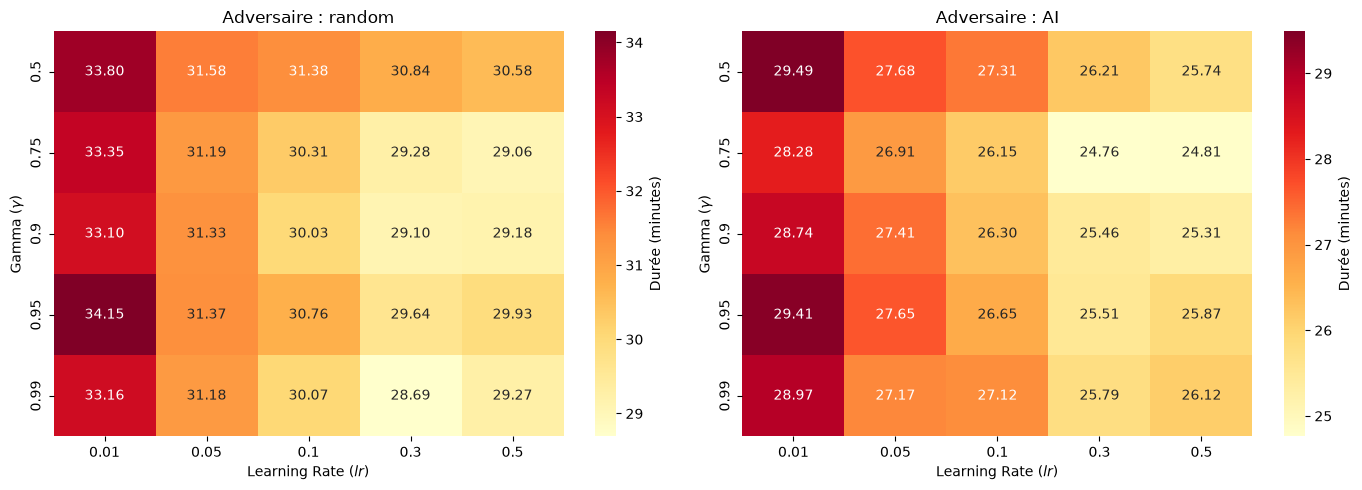

In [3]:
# Traitement direct de la sortie texte du terminal sans réexécuter les expériences
log_data = """
[OK] opponent=random gamma=0.5  lr=0.5  30.58 min
[OK] opponent=random gamma=0.5  lr=0.3  30.84 min
[OK] opponent=random gamma=0.5  lr=0.1  31.38 min
[OK] opponent=random gamma=0.5  lr=0.05 31.58 min
[OK] opponent=random gamma=0.5  lr=0.01 33.80 min
[OK] opponent=random gamma=0.75 lr=0.3  29.28 min
[OK] opponent=random gamma=0.75 lr=0.1  30.31 min
[OK] opponent=random gamma=0.75 lr=0.05 31.19 min
[OK] opponent=random gamma=0.75 lr=0.5  29.06 min
[OK] opponent=random gamma=0.75 lr=0.01 33.35 min
[OK] opponent=random gamma=0.9  lr=0.3  29.10 min
[OK] opponent=random gamma=0.9  lr=0.1  30.03 min
[OK] opponent=random gamma=0.9  lr=0.05 31.33 min
[OK] opponent=random gamma=0.9  lr=0.5  29.18 min
[OK] opponent=random gamma=0.9  lr=0.01 33.10 min
[OK] opponent=random gamma=0.95 lr=0.3  29.64 min
[OK] opponent=random gamma=0.95 lr=0.05 31.37 min
[OK] opponent=random gamma=0.95 lr=0.1  30.76 min
[OK] opponent=random gamma=0.95 lr=0.5  29.93 min
[OK] opponent=random gamma=0.95 lr=0.01 34.15 min
[OK] opponent=random gamma=0.99 lr=0.3  28.69 min
[OK] opponent=random gamma=0.99 lr=0.1  30.07 min
[OK] opponent=random gamma=0.99 lr=0.05 31.18 min
[OK] opponent=random gamma=0.99 lr=0.5  29.27 min
[OK] opponent=random gamma=0.99 lr=0.01 33.16 min
[OK] opponent=AI     gamma=0.5  lr=0.05 27.68 min
[OK] opponent=AI     gamma=0.5  lr=0.3  26.21 min
[OK] opponent=AI     gamma=0.5  lr=0.5  25.74 min
[OK] opponent=AI     gamma=0.5  lr=0.1  27.31 min
[OK] opponent=AI     gamma=0.5  lr=0.01 29.49 min
[OK] opponent=AI     gamma=0.75 lr=0.3  24.76 min
[OK] opponent=AI     gamma=0.75 lr=0.5  24.81 min
[OK] opponent=AI     gamma=0.75 lr=0.1  26.15 min
[OK] opponent=AI     gamma=0.75 lr=0.05 26.91 min
[OK] opponent=AI     gamma=0.75 lr=0.01 28.28 min
[OK] opponent=AI     gamma=0.9  lr=0.3  25.46 min
[OK] opponent=AI     gamma=0.9  lr=0.1  26.30 min
[OK] opponent=AI     gamma=0.9  lr=0.05 27.41 min
[OK] opponent=AI     gamma=0.9  lr=0.5  25.31 min
[OK] opponent=AI     gamma=0.9  lr=0.01 28.74 min
[OK] opponent=AI     gamma=0.95 lr=0.3  25.51 min
[OK] opponent=AI     gamma=0.95 lr=0.1  26.65 min
[OK] opponent=AI     gamma=0.95 lr=0.5  25.87 min
[OK] opponent=AI     gamma=0.95 lr=0.05 27.65 min
[OK] opponent=AI     gamma=0.95 lr=0.01 29.41 min
[OK] opponent=AI     gamma=0.99 lr=0.3  25.79 min
[OK] opponent=AI     gamma=0.99 lr=0.05 27.17 min
[OK] opponent=AI     gamma=0.99 lr=0.1  27.12 min
[OK] opponent=AI     gamma=0.99 lr=0.5  26.12 min
[OK] opponent=AI     gamma=0.99 lr=0.01 28.97 min
"""

pattern = re.compile(
    r"\[OK\] opponent=(\S+)\s+gamma=(\S+)\s+lr=(\S+)\s+([\d\.]+) min"
)

parsed_data = []
for line in log_data.strip().split("\n"):
    match = pattern.search(line)
    if match:
        opp, g, lr, dur = match.groups()
        parsed_data.append(
            {
                "opponent": opp,
                "gamma": float(g),
                "lr": float(lr),
                "duration_min": float(dur),
            }
        )

df_results = pd.DataFrame(parsed_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, opponent in zip(axes, ["random", "AI"]):
    pivot = df_results[df_results["opponent"] == opponent].pivot(
        index="gamma", columns="lr", values="duration_min"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        cbar_kws={"label": "Durée (minutes)"},
        ax=ax,
    )

    ax.set_title(f"Adversaire : {opponent}")
    ax.set_xlabel("Learning Rate ($lr$)")
    ax.set_ylabel("Gamma ($\\gamma$)")

plt.tight_layout()
plt.show()

### Interpretation of heatmaps

L'analyse des cartes thermiques met en évidence deux facteurs principaux expliquant les durées d'exécution:

* **Taux d'apprentissage ($lr$)**: C'est le facteur le plus déterminant. Un $lr$ plus élevé ($\ge 0.3$) permet aux Q-valeurs de se stabiliser rapidement vers des actions préférentielles, ce qui réduit le nombre moyen de coups nécessaires pour terminer une partie. À l'inverse, un $lr$ faible ($0.01$) maintient l'agent dans une phase d'hésitation plus longue, augmentant le nombre de coups par épisode et donc le temps total de calcul.
* **Type d'adversaire (`AI` vs `random`)**: L'entraînement contre l'adversaire `AI` est plus rapide (~25-29 min) que contre `random` (~28-34 min). L'adversaire `AI` joue selon une stratégie structurée qui provoque une fin de partie (victoire ou défaite) en moins de coups. L'adversaire `random` effectue des coups incohérents, ce qui prolonge artificiellement la durée moyenne des parties avant d'atteindre un état terminal.
* **Facteur de remise ($\gamma$)**: Son impact sur le temps d'exécution est négligeable. Bien que $\gamma$ modifie la pondération des récompenses futures et influence la stratégie finale adoptée par l'agent, il n'accélère ni ne ralentit la vitesse de décision ou la durée moyenne des parties au cours de l'apprentissage.

## 9. Data Loading & Extraction

Nous parcourons l'arborescence du dossier `experiments/` afin de charger automatiquement les métadonnées (`metadata.json`) et de parser le journal d'exécution (`output.txt`) de chaque expérience. 

Deux DataFrames Pandas sont générés:
1. `df_experiments`: Synthèse globale des 50 configurations (paramètres, durée d'exécution)
2. `df_epochs`: Suivi détaillé par époque (2 500 entrées au total : 50 expériences × 50 époques)

In [4]:
def load_and_parse_experiments(
    base_dir: str | Path = "experiments",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    base_path = Path(base_dir)

    experiment_records = []
    epoch_records = []

    epoch_header_pattern = re.compile(
        r"=============\s*Epoch\s*(\d+)\s*============="
    )
    duration_pattern = re.compile(r"Duration:\s*([\d\.]+)\s*minutes")

    re_eps = re.compile(r"Epsilon:\s*([\d\.]+)")
    re_states = re.compile(r"Explored States:\s*(\d+)")
    re_win = re.compile(r"Epoch Win Rate:\s*([\d\.]+)%")
    re_moves = re.compile(r"Avg Moves/Match:\s*([\d\.]+)")
    re_reward = re.compile(r"Avg Reward/Episode:\s*(-?[\d\.]+)")

    output_files = list(base_path.glob("**/output.txt"))

    for log_file in output_files:
        exp_dir = log_file.parent
        json_file = exp_dir / "metadata.json"

        if not json_file.exists():
            continue

        with open(json_file, "r", encoding="utf-8") as f:
            meta = json.load(f)

        opponent = meta.get("opponent", exp_dir.parent.name)
        exp_name = meta.get("experiment_name", exp_dir.name)
        # Unique identifier combining opponent and experiment directory name
        unique_id = f"{opponent}_{exp_name}"

        gamma = float(meta.get("gamma"))
        lr = float(meta.get("learning_rate"))

        text = log_file.read_text(encoding="utf-8")

        dur_match = duration_pattern.search(text)
        duration_min = float(dur_match.group(1)) if dur_match else None

        experiment_records.append(
            {
                "unique_id": unique_id,
                "experiment": exp_name,
                "opponent": opponent,
                "gamma": gamma,
                "lr": lr,
                "epochs": meta.get("epochs", 50),
                "episodes": meta.get("episodes", 10000),
                "duration_min": duration_min,
                "log_path": str(log_file),
            }
        )

        epoch_blocks = epoch_header_pattern.split(text)

        # Track epochs seen within THIS log file to prevent duplicate logging
        seen_epochs = set()

        for i in range(1, len(epoch_blocks), 2):
            epoch_num = int(epoch_blocks[i])
            block_text = epoch_blocks[i + 1]

            if epoch_num in seen_epochs or epoch_num >= 50:
                continue

            m_eps = re_eps.search(block_text)
            m_states = re_states.search(block_text)
            m_win = re_win.search(block_text)
            m_moves = re_moves.search(block_text)
            m_reward = re_reward.search(block_text)

            if m_eps and m_states and m_win and m_moves and m_reward:
                seen_epochs.add(epoch_num)
                epoch_records.append(
                    {
                        "unique_id": unique_id,
                        "experiment": exp_name,
                        "opponent": opponent,
                        "gamma": gamma,
                        "lr": lr,
                        "epoch": epoch_num,
                        "epsilon": float(m_eps.group(1)),
                        "explored_states": int(m_states.group(1)),
                        "win_rate": float(m_win.group(1)),
                        "avg_moves": float(m_moves.group(1)),
                        "avg_reward": float(m_reward.group(1)),
                    }
                )

    df_experiments = pd.DataFrame(experiment_records)
    df_epochs = pd.DataFrame(epoch_records)

    return df_experiments, df_epochs


df_experiments, df_epochs = load_and_parse_experiments("experiments")

print(f"Unique experiments: {df_epochs['unique_id'].nunique()} / {total_experiments}")
print(f"Total epoch rows: {len(df_epochs)} / {total_experiments * epochs}")

Unique experiments: 50 / 50
Total epoch rows: 2500 / 2500


In [5]:
def find_corrupted_experiments():
    # Group by both opponent and experiment to inspect each of the runs individually
    grouped = df_epochs.groupby(["opponent", "experiment"]).size()

    found = 0
    for (opp, exp), count in grouped.items():
        if count < 50:
            found += 1
            # Find corresponding log file path from df_experiments
            log_path = df_experiments[
                (df_experiments["opponent"] == opp)
                & (df_experiments["experiment"] == exp)
            ]["log_path"].values[0]

            parsed_epochs = df_epochs[
                (df_epochs["opponent"] == opp) & (df_epochs["experiment"] == exp)
            ]["epoch"].tolist()

            missing = sorted(list(set(range(total_experiments)) - set(parsed_epochs)))

            print(f"[{opp} | {exp}]")
            print(f"  Parsed epochs: {count}/{total_experiments}")
            print(f"  Missing epochs: {missing}")
            print(f"  Log file: {log_path}\n")
    
    print(f"\nTotal corrupted experiments: {found}")

find_corrupted_experiments()


Total corrupted experiments: 0


# 10. Q-Learning Analysis

Maintenant que nous avons toutes les donnees necessaires, nous creeons une fonction pour eviter de dupliquer le code pour *Random* et *AI*. 

In [6]:
def win_rate_progression(opponent: str) -> None:
    """
    Args:
        opponent (str): Either "random" or "AI".
    """
    # Filter for random opponent only
    df_temp = df_epochs[df_epochs["opponent"] == opponent].copy()

    # IDENTIFY BEST MODEL

    # Calculate final 10 epochs mean win rate per experiment
    summary = (
        df_temp[df_temp["epoch"] >= 40]
        .groupby(["gamma", "lr"])
        .agg(
            avg_win_rate_last10=("win_rate", "mean"),
            max_win_rate_last10=("win_rate", "max"),
            std_win_rate_last10=("win_rate", "std"),
        )
        .reset_index()
    )

    # Also get final epoch (49) win rate
    final_epoch_df = df_temp[df_temp["epoch"] == epochs-1][
        ["gamma", "lr", "win_rate"]
    ].rename(columns={"win_rate": "final_epoch_win_rate"})

    summary = pd.merge(
        summary, final_epoch_df, on=["gamma", "lr"]
    ).sort_values(by=["avg_win_rate_last10", "final_epoch_win_rate"], ascending=False)

    print(f"TOP 10 EXPERIMENTS AGAINST {opponent.upper()} OPPONENT\n")
    print(summary.head(n=10).to_markdown(index=False))

    best_gamma = summary.iloc[0]["gamma"]
    best_lr = summary.iloc[0]["lr"]
    best_exp_name = f"gamma_{best_gamma}_lr_{best_lr}"

    print(
        f"\nBest Experiment Overall: gamma={best_gamma}, lr={best_lr} "
        f"(Last 10 Epoch Avg Win Rate: {summary.iloc[0]['avg_win_rate_last10']:.2f}%)"
    )

    # DRAW GRAPH (All 25 Experiments)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

    gammas = sorted(df_temp["gamma"].unique())
    learning_rates = sorted(df_temp["lr"].unique())

    # Color palette for learning rates
    colors = sns.color_palette("viridis", len(learning_rates))
    lr_color_map = dict(zip(learning_rates, colors))

    for idx, gamma_val in enumerate(gammas):
        ax = axes[idx]
        sub_df = df_temp[df_temp["gamma"] == gamma_val]

        for lr_val in learning_rates:
            exp_df = sub_df[sub_df["lr"] == lr_val].sort_values("epoch")

            is_best = (gamma_val == best_gamma) and (lr_val == best_lr)

            ax.plot(
                exp_df["epoch"],
                exp_df["win_rate"],
                label=f"lr={lr_val}",
                color="red" if is_best else lr_color_map[lr_val],
                linewidth=3.0 if is_best else 1.2,
                linestyle="-" if is_best else "--",
                zorder=10 if is_best else 2,
            )

        ax.set_title(f"$\\gamma = {gamma_val}$", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        if idx == 0:
            ax.set_ylabel("Win Rate (%)")
        ax.set_ylim(-5, 105)

    # Place unified legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(learning_rates),
        title="Learning Rate ($lr$)",
    )

    plt.suptitle(
        f"Win Rate Progression Across 50 Epochs vs. {opponent.capitalize() if opponent == 'random' else opponent} Opponent (Highlighted Best: $\\gamma={best_gamma}, lr={best_lr}$)",
        y=1.15,
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 10.1 AI vs Random Progression

TOP 10 EXPERIMENTS AGAINST RANDOM OPPONENT

|   gamma |   lr |   avg_win_rate_last10 |   max_win_rate_last10 |   std_win_rate_last10 |   final_epoch_win_rate |
|--------:|-----:|----------------------:|----------------------:|----------------------:|-----------------------:|
|    0.75 |  0.5 |                 92.48 |                  94.2 |              1.58661  |                   94.2 |
|    0.95 |  0.5 |                 92.2  |                  95.2 |              1.71788  |                   92.8 |
|    0.9  |  0.5 |                 91.78 |                  94.4 |              1.78251  |                   92.6 |
|    0.9  |  0.3 |                 91.68 |                  95   |              1.90485  |                   91.8 |
|    0.75 |  0.3 |                 91.44 |                  93.2 |              0.815407 |                   90.8 |
|    0.99 |  0.3 |                 91.44 |                  93.6 |              1.56574  |                   89.4 |
|    0.95 |  0.3 |          

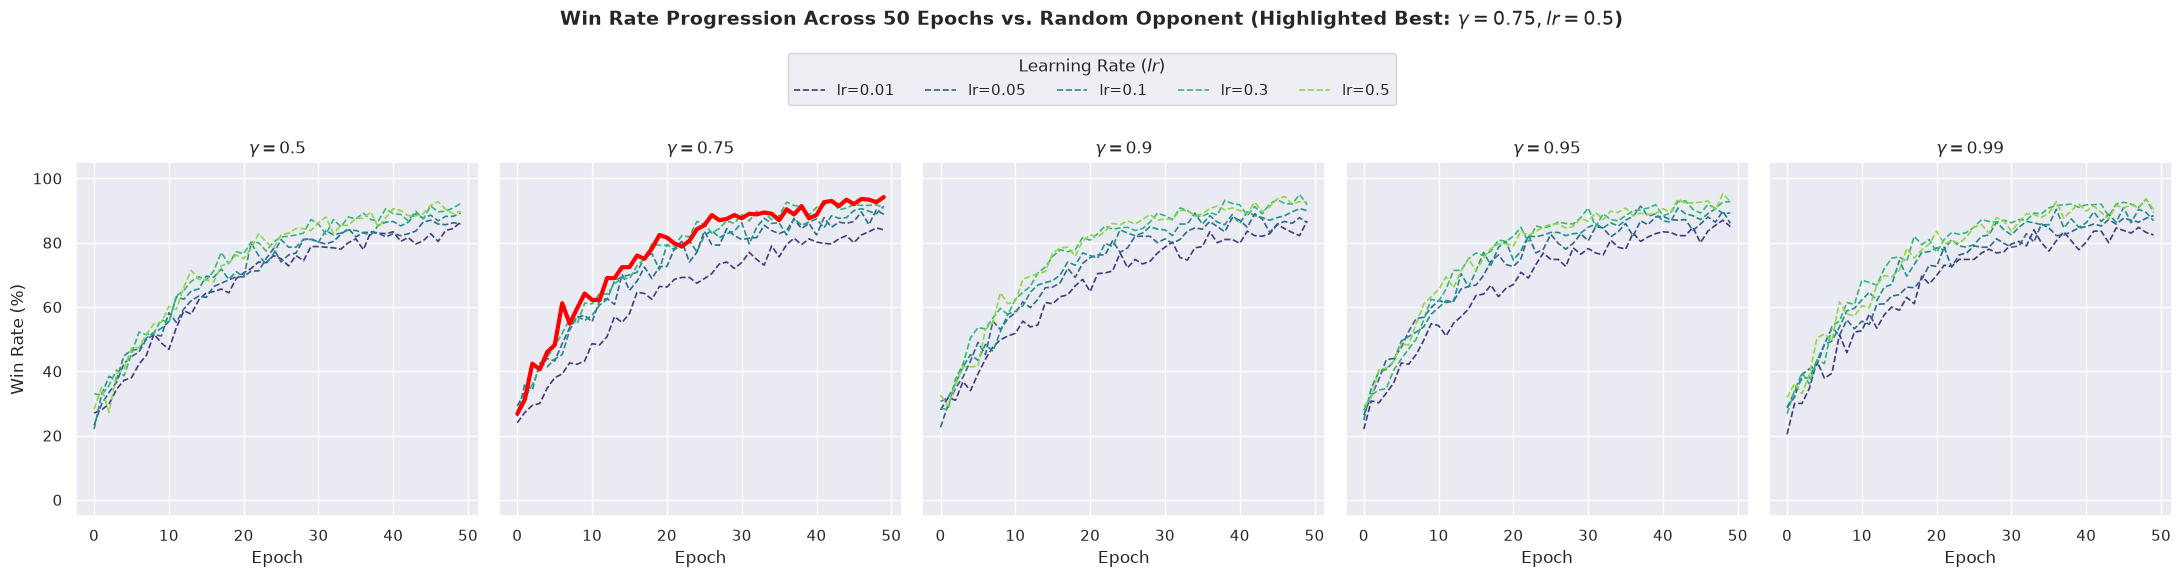

In [7]:
win_rate_progression("random")

### Key analytical takeaways (AI vs Random)
1. **Domination du taux d'apprentissage ($lr$)**
    - $lr = 0.5$ et $lr = 0.3$ occupent l'intégralité du top 10. $lr = 0.5$ détient les 3 meilleures configurations ( $\gamma = 0.75, 0.95, 0.9$).
    - Les taux d'apprentissage plus faibles ($lr \le 0.1$) n'ont pas réussi à atteindre leur performance maximale en 50 époques (500k episodes en total)  
    probablement en raison de mises à jour de Q-valeurs trop lentes par épisode.
2. **Trajectoire de convergence**
    - Face à un adversaire aléatoire, des taux d'apprentissage élevés ($lr = 0.5$) permettent aux Q-valeurs de s'adapter rapidement aux actions non déterministes,  
    franchissant la barre des $80\%$ de taux de victoire dès l'époque 20–25 sur l'ensemble des sous-graphiques $\gamma$.
    - $lr = 0.01$ reste systématiquement en bas de chaque graphique, nécessitant nettement plus de 50 époques pour converger.
3. **Impact du facteur de réfaction ($\gamma$)**
    - $\gamma = 0.75$ **offre l'équilibre optimal** entre la pondération des récompenses immédiates et futures face à un jeu aléatoire,  
    atteignant un taux de victoire moyen maximal de $92.48\%$ (pic à $94.2\%$) avec une faible variance ($\sigma = 1.59\%$).
    - Fixer $\gamma = 0.99$ augmente le coût de propagation des valeurs sur un horizon long, ce qui réduit légèrement les performances  
    contre des coups aléatoires par rapport à $\gamma = 0.75$ ou $\gamma = 0.95$.

## 10.2 AI vs AI Progression

TOP 10 EXPERIMENTS AGAINST AI OPPONENT

|   gamma |   lr |   avg_win_rate_last10 |   max_win_rate_last10 |   std_win_rate_last10 |   final_epoch_win_rate |
|--------:|-----:|----------------------:|----------------------:|----------------------:|-----------------------:|
|    0.9  |  0.5 |                 74.88 |                  78.4 |               2.7844  |                   74.6 |
|    0.95 |  0.5 |                 74.68 |                  77   |               2.20947 |                   74.4 |
|    0.75 |  0.3 |                 73.36 |                  75.6 |               1.49904 |                   73.6 |
|    0.75 |  0.5 |                 73.02 |                  76.8 |               2.48453 |                   75.4 |
|    0.5  |  0.5 |                 72.44 |                  74.4 |               1.79827 |                   73   |
|    0.99 |  0.5 |                 72.32 |                  77.6 |               3.26354 |                   67.4 |
|    0.99 |  0.3 |              

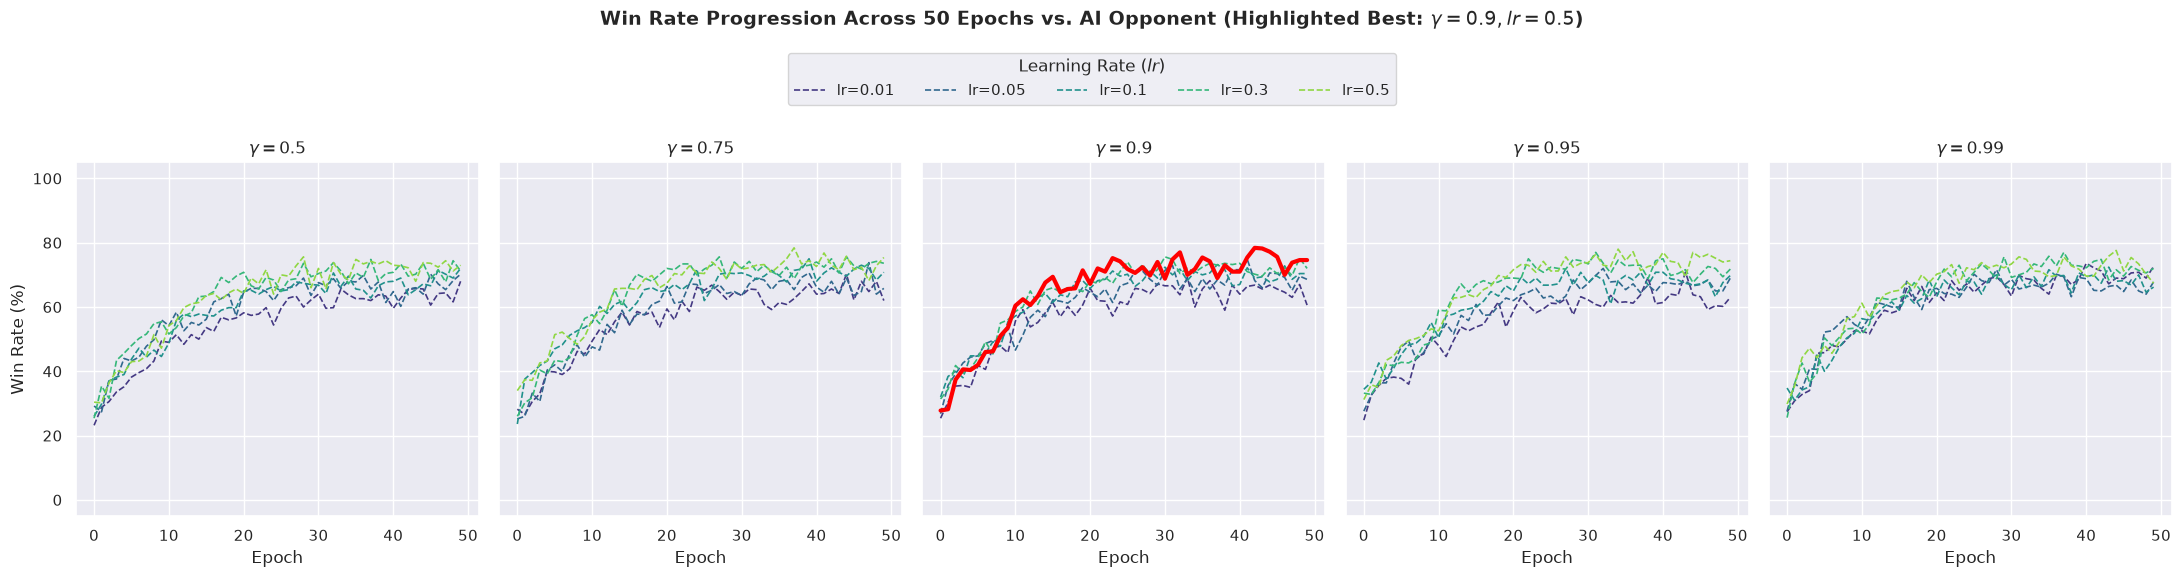

In [8]:
win_rate_progression("AI")

### Key Analytical Takeaways (AI vs AI)
1. **Baisse du plafond de performance ($\sim 75\%$ contre $\sim 92\%$)**
    - **Plafond stratégique:** Le meilleur taux de victoire moyen chute de $92.48\%$ (entrainement contre adversaire aléatoire) à $74.88\%$ (entrainement contre IA).  
    Ceci pourrait s'expliquer par le fait que l'adversaire IA suit des règles heuristiques déterministes et structurées.  
    Contrairement au joueur aléatoire qui commet des erreurs exploitables à chaque tour, l'IA bloque systématiquement les coups simplistes,  
    imposant une limite aux opportunités de victoire faciles.
2. **Hausse du $\gamma$ optimal**
    - **Glissement vers le long terme:** Le paramètre optimal passe de $\gamma = 0.75$ (contre *Random*) à $\gamma = 0.90/0.95$ (contre *AI*).  
    Une vision tactique à court/moyen terme ($\gamma = 0.75$) suffit à punir des coups chaotiques.  
    En revanche, battre une IA heuristique exige d'anticiper les combinaisons sur plusieurs coups à l'avance.
3. **Instabilité de la valeur extrême ($\gamma = 0.99$)**
    - **Variance la plus élevée:** La configuration $\gamma = 0.99, lr = 0.5$ enregistre le plus fort écart-type ($\sigma = 3.26\%$) et une baisse sur la dernière époque ($67,4\%$).  
    Propager la valeur des récompenses sur un horizon quasi infini ($\gamma = 0.99$) combiné à un fort taux d'apprentissage ($lr = 0.5$)  
    crée un surajustement aux contrecoups déterministes de l'IA, entraînant une instabilité des Q-valeurs.

| Steps in Future ($k$) | Weight with $\gamma = 0.75$ | Weight with $\gamma = 0.99$ |
|---|---|---:|
| 1 step | 75.0% | 99.0% |
| 5 steps | 23.7% | 95.1% |
| 10 steps | 5.6% | 90.4% |
| 20 steps | 0.3% | 81.8% |
| 50 steps | 0.00005% | 60.5% |

Donc, avec $\gamma = 0.99$, une mauvaise estimation de valeur située plusieurs coups plus loin n'est quasiment pas atténuée lorsqu'elle est propagée vers l'arrière ($0.99^k \approx 1$).  
Si une Q-valeur est temporairement faussée (par exemple durant une phase d'exploration $\epsilon\text{-greedy}$), cette erreur contamine l'ensemble des états précédents de la chaîne.

4. **Constante du taux d'apprentissage ($lr = 0.5$)**  
    Comme pour l'adversaire aléatoire, $lr = 0.5$ et $lr = 0.3$ occupent toutes les positions du top 10.  
    Sur une fenêtre restreinte de 50 époques, des mises à jour agressives des Q-valeurs restent indispensables pour que l'agent apprenne à contrer l'IA avant la fin du budget d'entraînement.

## 11. Top AI (trained with random) vs Top AI (trained with AI)

Finalement, nous testons les deux meilleures IA, une IA entraine contre un *Random* et une autre IA entraine contre une IA, sur 500 match avec la commande:
```
python main.py \
    --game cubee --no-launch --efficiency 3 --log WARNING \
    --test --test-matches 500 --epsilon 0 \
    --qtable-path ./cubee/QTables/opponent_random/epochs_50-eps_10000-gamma_0.75-lr_0.5-epsilon_1.0-epscoeff_0.95-mineps_0.05/epoch_49.pkl \
    ./cubee/QTables/opponent_AI/epochs_50-eps_10000-gamma_0.9-lr_0.5-epsilon_1.0-epscoeff_0.95-mineps_0.05/epoch_49.pkl
```

### Results

| Perf. Label / AI | AI 1 (trained against Random) | AI 2 (trained against AI) |
|---|---|---:|
| Epsilon | 0.0000 | 0.0000 |
| Explored States | 5641078 | 8268435 |
| Win Rate | 30.60% (153/500) | 63.80% (319/500) |
| Avg Moves/Match | 13.7 | 13.8 |
| Avg Reward/Episode | 16.16 | 28.82 |
|Draws | 28 (5.60%) | 28 (5.60%) |

### Interpretation

L'affrontement direct entre les deux agents confirme nettement la supériorité de l'entraînement face à un adversaire structuré plutôt qu'aléatoire.

* **Domination de l'IA 2 (Win Rate : $63.80\%$ vs $30.60\%$):**  
  L'IA 2 surclasse largement l'IA 1.  
  L'entraînement contre un agent intelligent force le modèle à développer des compétences avancées d'anticipation,  
  de contrôle de territoire et de blocage.  
  À l'inverse, l'IA 1 a développé une politique opportuniste adaptée aux erreurs de l'adversaire aléatoire,  
  devenant vulnérable face à une stratégie construite.

* **Couverture de l'espace d'états (Explored States):**  
  L'IA 2 a visité davantage d'états (8,268,435 contre 5,641,078).  
  Cette exploration accrue découle de parties d'entraînement plus disputées et complexes,  
  lui conférant des Q-valeurs mieux ajustées pour faire face à des situations variées.

* **Différence de récompense moyenne ($28.82$ vs $16.16$):**  
  La récompense moyenne nettement plus élevée de l'IA 2 reflète son efficacité à maximiser la capture de cases et d'enclos tout au long de la partie,  
  tandis que l'IA 1 peine à sécuriser du territoire face à un opposant qui ne concède pas de cases gratuitement.

* **Matchs nuls et boucles déterministes ($5.60\%$):**  
  Les 28 matchs nuls observés correspondent aux parties ayant atteint la limite maximale de 200 tours.  
  À $\epsilon = 0$, les deux agents jouent de manière strictement déterministe.  
  Lorsque l'état du plateau conduit à un cycle fermé d'actions répétitives sans qu'aucun agent ne trouve un coup supérieur,  
  la partie se bloque dans une boucle infinie interrompue par le contrôleur.

# Demonstration

<video controls src="demo.mkv" width="1280" height="720">